In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())
import sequenceHandler  
import importlib
importlib.reload(sequenceHandler)
from sequenceHandler import distance_map_PDB
import torch.nn as nn
from torch_geometric.nn import MessagePassing, LayerNorm
import torch.nn.functional as F
from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve, precision_recall_curve
from torch_geometric.utils import softmax

3989607


In [3]:
folder_DCA="Data"
folder_PDB="PDB"
thres=8.0
learning_rate=0.001
minimum_separation=0

In [4]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [ ]:
def contact_from_distance(distance_map, threshold=thres):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  

#function to take the top k element of a matrix (excludin the ones masked) 
def top_k_mask(matrix, k, mask=None):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    if mask is not None:
        mask_vals = mask[triu_indices]
        #make the masked point distant -inf
        values = np.where(mask_vals, values, -np.inf)

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask_out = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask_out[rows, cols] = 1
    mask_out[cols, rows] = 1

    return mask_out

In [6]:
#how to store the data

def build_graph_contact(noisy_contact_map, distance_map=None, sep_min=minimum_separation):
    
    N = len(noisy_contact_map)

    # contact map to tensor
    noisy_contact_map = torch.tensor(noisy_contact_map, dtype=torch.float)

    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')  # shape [N, N]

    # masks
    not_self = i != j
    pair_mask = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    if distance_map is not None:
        known = np.isfinite(distance_map)
        known = torch.tensor(known, dtype=torch.bool)
        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        true_contact_map = torch.tensor(true_contact_map, dtype=torch.float)
        labels = (known & (true_contact_map == 1)).float()
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels = torch.zeros((N, N), dtype=torch.float)

    edge_mask = known & long_range_ok
     # remove i == j
    valid = not_self

    src = i[valid]
    dst = j[valid]

    edge_index = torch.stack([src, dst], dim=0)
    edge_attr = noisy_contact_map[valid].unsqueeze(-1)
    y = labels[valid].unsqueeze(-1) 
        
    mask = edge_mask[valid]
    pair_mask = pair_mask[valid]

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,                 # binary contact labels
        edge_mask=mask,      # valid + long-range
        pair_mask=pair_mask, # only one direction per pair
        L=N
    )

In [7]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [8]:
def model_size(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(
        p.numel() for p in model.parameters()
        if p.requires_grad
    )

    print(f"Total parameters:      {total_params:,}")
    print(f"Trainable parameters:  {trainable_params:,}")
    print(f"Non-trainable params:  {total_params - trainable_params:,}")

In [9]:
class AttentionMPLayer(MessagePassing):
    """Single attention-based message-passing layer (node + edge updates)."""

    def __init__(self, hidden_dim, heads=4, dropout=0.0):
        super().__init__(node_dim=0, aggr='add', flow='source_to_target')

        self.hidden_dim = hidden_dim
        self.heads = heads
        self.head_dim = hidden_dim // heads
        self.dropout = dropout

        assert hidden_dim % heads == 0, "hidden_dim must be divisible by heads"

        # Edge update MLP: [x_i, x_j, e_ij] -> e'_ij
        self.edge_mlp = nn.Sequential(
            nn.Linear(3 * hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # Attention projections (Q, K spaces)
        self.att_lin_i = nn.Linear(hidden_dim, heads * self.head_dim, bias=False)
        self.att_lin_j = nn.Linear(hidden_dim, heads * self.head_dim, bias=False)
        self.att_lin_e = nn.Linear(hidden_dim, heads * self.head_dim, bias=False)
        self.att_vec = nn.Parameter(torch.Tensor(1, heads, self.head_dim))

        # Message projections (V space)
        self.pay_lin_j = nn.Linear(hidden_dim, heads * self.head_dim, bias=False)
        self.pay_lin_e = nn.Linear(hidden_dim, heads * self.head_dim, bias=False)

        # Node update MLP: [x_i, aggregated_messages] -> x'_i
        self.node_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.att_lin_i.weight)
        nn.init.xavier_uniform_(self.att_lin_j.weight)
        nn.init.xavier_uniform_(self.att_lin_e.weight)
        nn.init.xavier_uniform_(self.pay_lin_j.weight)
        nn.init.xavier_uniform_(self.pay_lin_e.weight)
        nn.init.xavier_uniform_(self.att_vec)

    def forward(self, x, edge_index, edge_attr):
        edge_attr_new = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        message = self.propagate(edge_index, x=x, edge_attr=edge_attr_new)
        x_new = self.node_mlp(torch.cat([x, message], dim=-1))
        return x_new, edge_attr_new

    def edge_update(self, x_i, x_j, edge_attr):
        return self.edge_mlp(torch.cat([x_i, x_j, edge_attr], dim=-1))

    def message(self, x_i, x_j, edge_attr, index, ptr, size_i):
        q_i = self.att_lin_i(x_i).view(-1, self.heads, self.head_dim)
        k_j = self.att_lin_j(x_j).view(-1, self.heads, self.head_dim)
        k_e = self.att_lin_e(edge_attr).view(-1, self.heads, self.head_dim)

        score = F.leaky_relu(q_i + k_j + k_e, 0.2)
        alpha = (score * self.att_vec).sum(dim=-1)
        alpha = softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        v_j = self.pay_lin_j(x_j).view(-1, self.heads, self.head_dim)
        v_e = self.pay_lin_e(edge_attr).view(-1, self.heads, self.head_dim)
        return (v_j + v_e) * alpha.unsqueeze(-1)

    def update(self, inputs, x):
        return inputs.view(-1, self.heads * self.head_dim)


class MP_GNN(nn.Module):
    """
    Attention MPNN for edge classification + SAGE contrastive learning.

    Returns (x_sage, out_reg, out_cls):
      x_sage   — L2-normalized node embeddings at layer num_layers_sage (for SAGE loss)
      out_reg  — per-edge regression logits [E]
      out_cls  — per-edge classification logits [E]
    """

    def __init__(self, num_layers=6, num_heads=2,
                 node_in_dim=16, edge_in_dim=16, latent_dim=32):
        super().__init__()

        assert latent_dim % num_heads == 0, "latent_dim must be divisible by num_heads"

        
        self.node_in_dim = node_in_dim
        self.edge_in_dim = edge_in_dim

        self.in_x_proj = nn.Linear(node_in_dim, latent_dim)
        self.in_e_proj = nn.Linear(edge_in_dim, latent_dim)

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList()
        self.edge_norms = nn.ModuleList()
        for _ in range(num_layers):
            self.node_norms.append(LayerNorm(latent_dim))
            self.edge_norms.append(LayerNorm(latent_dim))
            self.convs.append(AttentionMPLayer(hidden_dim=latent_dim, heads=num_heads, dropout=0.1))

        self.out_cls = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Linear(latent_dim, 1)
        )

    def forward(self, graph):
        x, edge_index, edge_attr = graph.x, graph.edge_index, graph.edge_attr

        x = self.in_x_proj(x)
        edge_attr = self.in_e_proj(edge_attr)

        for i, (conv, node_norm, edge_norm) in enumerate(zip(self.convs, self.node_norms, self.edge_norms)):
            x = node_norm(x)
            edge_attr = edge_norm(edge_attr)
            x_new, edge_attr_new = conv(x, edge_index, edge_attr)
            x = x + x_new
            edge_attr = edge_attr + edge_attr_new

        out_cls = self.out_cls(edge_attr).squeeze(-1)
        return out_cls

In [10]:
#how to evaluate the precision of the top kL contact for each graph
def topk_L_precision(model, loader, device, ratio=1.0):
    model.eval()
    per_graph_precisions = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)

            probs = torch.sigmoid(logits.squeeze(-1))
            true_contacts = batch.y.squeeze(-1)

            valid_mask = batch.edge_mask & batch.pair_mask

            # graph id for each edge
            edge_graph_id = batch.batch[batch.edge_index[0]]

            num_graphs = batch.num_graphs

            for g in range(num_graphs):
                graph_mask = valid_mask & (edge_graph_id == g)

                probs_g = probs[graph_mask]
                true_g = true_contacts[graph_mask]

                if probs_g.numel() == 0:
                    continue

                # length of the protein
                L = int(batch.L[g]) if torch.is_tensor(batch.L) else int(batch.L)

                k = max(1, int(L * ratio))
                k = min(k, probs_g.numel())

                top_idx = torch.topk(probs_g, k=k).indices
                #knumber of true contacts in top-k​/k
                precision_g = (true_g[top_idx] > 0.5).float().mean().item()

                per_graph_precisions.append(precision_g)

    return float(np.mean(per_graph_precisions)), per_graph_precisions

In [11]:
def graph_to_matrix(data, values):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

In [12]:
class AsymmetricLoss(nn.Module):
    def __init__(
        self,
        gamma_neg=6,
        gamma_pos=1,
        clip=0.05,
        eps=1e-8
    ):
        super().__init__()

        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        # optional clipping
        if self.clip is not None and self.clip > 0:
            probs_neg = (1 - probs + self.clip).clamp(max=1)
        else:
            probs_neg = 1 - probs

        pos_loss = targets * torch.log(probs.clamp(min=self.eps))
        neg_loss = (1 - targets) * torch.log(
            probs_neg.clamp(min=self.eps)
        )

        pos_weight = (1 - probs) ** self.gamma_pos
        neg_weight = probs ** self.gamma_neg

        loss = -(
            pos_weight * pos_loss
            + neg_weight * neg_loss
        )

        return loss.mean()

<- functions and class

In [13]:
folder_path = folder_DCA

all_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        L= loaded['distance_map'].shape[0]
        K = 5 * L
        binary_map = top_k_mask(loaded['dca'], K)
        data = build_graph_contact(binary_map, loaded['distance_map'], minimum_separation)
        all_data.append(data)


Number of Data:1561


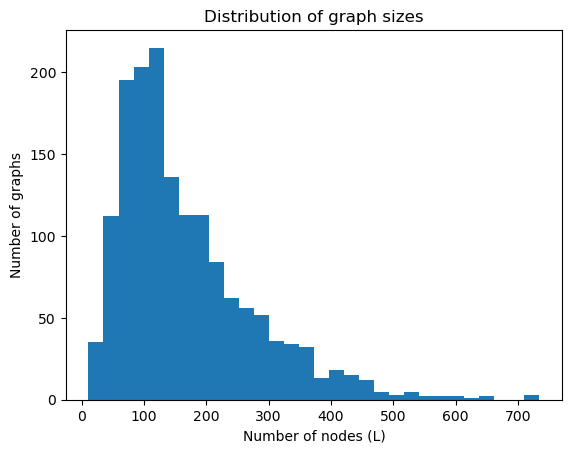

In [14]:
print(f"Number of Data:{len(all_data)}")

lengths = [data.num_nodes for data in all_data]

plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Number of nodes (L)")
plt.ylabel("Number of graphs")
plt.title("Distribution of graph sizes")
plt.show()

Number of PDB:1561


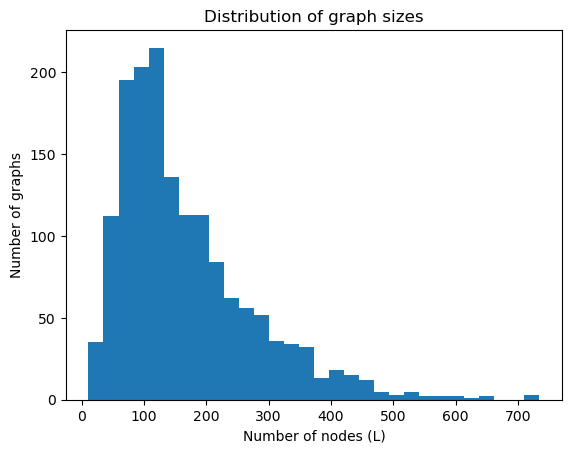

In [15]:
#biggest PDB are removed for memory cost
MAX_NODES = 800

filtered_data = [data for data in all_data if data.num_nodes <= MAX_NODES]

print(f"Number of PDB:{len(filtered_data)}")
lengths = [data.num_nodes for data in filtered_data]

plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Number of nodes (L)")
plt.ylabel("Number of graphs")
plt.title("Distribution of graph sizes")
plt.show()

In [16]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_val_data, test_data = train_test_split(
    filtered_data,
    test_size=0.2,
    random_state=1
)

train_data, val_data = train_test_split(
    train_val_data,
    test_size=0.25,  
    random_state=1
)

train_loader = DataLoader(train_data, batch_size=1, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)
val_loader = DataLoader(val_data, batch_size=1,shuffle=True)

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MP_GNN(
    num_layers=4,
    num_heads=4,
    node_in_dim=16,
    edge_in_dim=1,
    latent_dim=64
).to(device)

model_size(model)

save_path = "best_model_cc_likeDCA_sep0_attention_true_data.pt"
#to load an old model
state_dict = torch.load(save_path)
model.load_state_dict(state_dict)



loss_fn = AsymmetricLoss(
    gamma_neg=8,
    gamma_pos=1
)



optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)   
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5, patience=10,min_lr=1e-6)


Total parameters:      205,377
Trainable parameters:  205,377
Non-trainable params:  0


In [19]:
train_losses = []
val_losses = []


best_val_loss = float('inf')
patience = 70
epochs_no_improve = 0

for epoch in range(3000):

    model.train()

    total_loss = 0.0
    total_edges = 0
    for batch in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()

        pred_logits = model(batch)

        pred_logits = pred_logits.squeeze(-1)
        true_contacts = batch.y.squeeze(-1)

        mask = batch.edge_mask #& batch.pair_mask

        loss = loss_fn(pred_logits[mask], true_contacts[mask])

        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        optimizer.step()

    train_loss = total_loss / max(total_edges, 1)

    model.eval()
    total_loss_val = 0.0
    total_edges_val = 0

    with torch.no_grad():

        loss_contact_tot=[]
        loss_regression_tot=[]
        for batch in val_loader:
            batch = batch.to(device)
            pred_logits = model(batch)
            pred_logits = pred_logits.squeeze(-1)
            true_contacts = batch.y.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss = loss_fn(pred_logits[mask], true_contacts[mask])

            n_edges = mask.sum().item()
            total_loss_val += loss.item() * n_edges
            total_edges_val += n_edges

    val_loss= total_loss_val / max(total_edges_val, 1)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

Epoch 0: Train Loss=0.0257, Val Loss=0.0229
Epoch 1: Train Loss=0.0236, Val Loss=0.0220
Epoch 2: Train Loss=0.0233, Val Loss=0.0216
Epoch 3: Train Loss=0.0231, Val Loss=0.0217
Epoch 4: Train Loss=0.0231, Val Loss=0.0216
Epoch 5: Train Loss=0.0230, Val Loss=0.0216
Epoch 6: Train Loss=0.0230, Val Loss=0.0216
Epoch 7: Train Loss=0.0228, Val Loss=0.0214
Epoch 8: Train Loss=0.0228, Val Loss=0.0213
Epoch 9: Train Loss=0.0226, Val Loss=0.0214
Epoch 10: Train Loss=0.0225, Val Loss=0.0211
Epoch 11: Train Loss=0.0224, Val Loss=0.0211
Epoch 12: Train Loss=0.0224, Val Loss=0.0212
Epoch 13: Train Loss=0.0222, Val Loss=0.0211
Epoch 14: Train Loss=0.0222, Val Loss=0.0212
Epoch 15: Train Loss=0.0221, Val Loss=0.0207
Epoch 16: Train Loss=0.0220, Val Loss=0.0207
Epoch 17: Train Loss=0.0218, Val Loss=0.0208
Epoch 18: Train Loss=0.0218, Val Loss=0.0207
Epoch 19: Train Loss=0.0217, Val Loss=0.0204
Epoch 20: Train Loss=0.0216, Val Loss=0.0203
Epoch 21: Train Loss=0.0215, Val Loss=0.0205
Epoch 22: Train Loss

In [63]:
print(optimizer.param_groups[0]['lr'])

0.0005


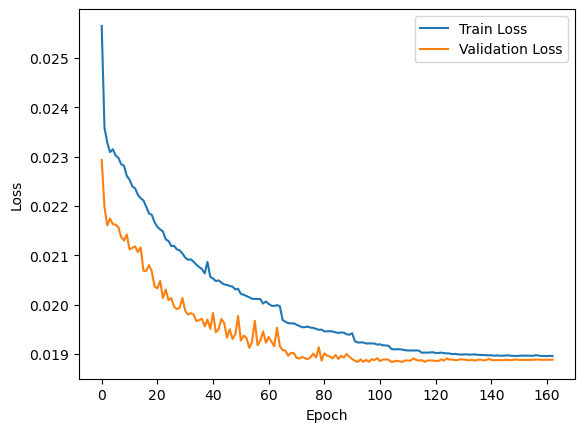

In [20]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model = MP_GNN(
    num_layers=4,
    num_heads=4,
    node_in_dim=16,
    edge_in_dim=1,
    latent_dim=64
).to(device)


save_path = "best_model_cc_likeDCA_sep0_attention_true_data.pt"

state_dict = torch.load(save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

Validation ROC AUC GNN: 0.9089547971727432


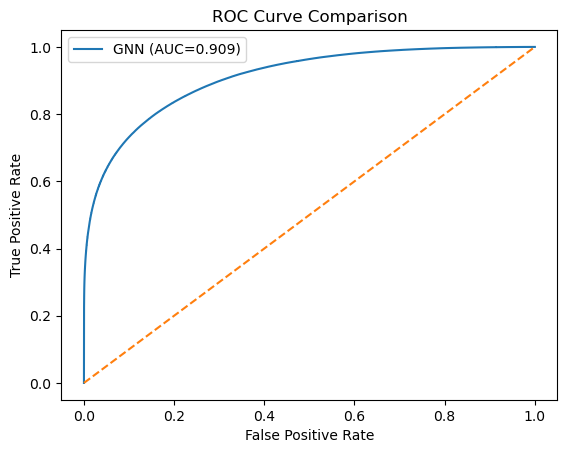

PR AUC GNN: 0.68754841222151


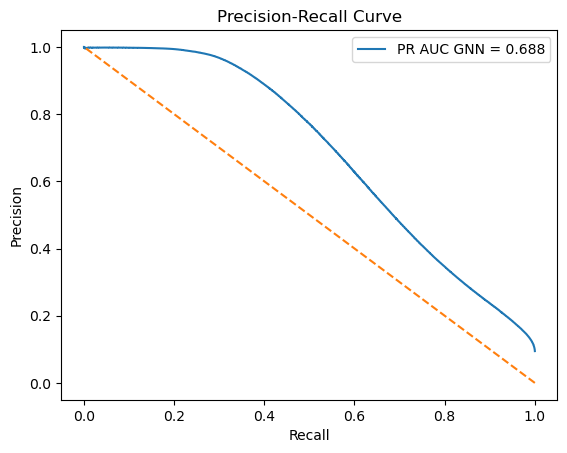

In [22]:
#ROC and Precision-Recall curve

model.eval()

all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)

    with torch.no_grad():
        pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask

    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)


# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()
plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [23]:
print("Top-k*L precision:", topk_L_precision(model, test_loader, device, ratio=5)[0])

Top-k*L precision: 0.8532519131041945


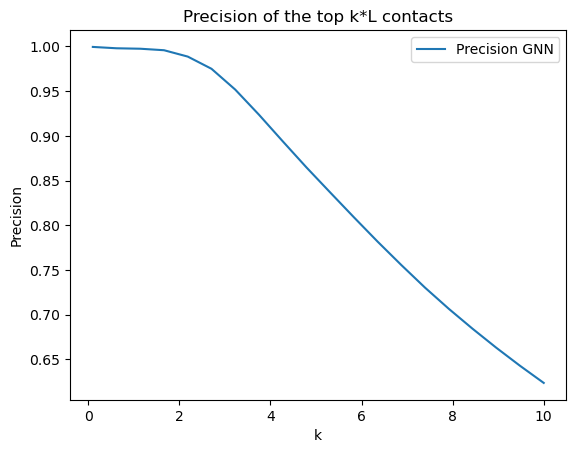

In [25]:
#precision in function of the number of contact to predict

total_k=np.linspace(0.1,10,20)
p_GNN=[]

for k in total_k:
    prec=[]

    for batch in test_loader:
        batch = batch.to(device)

        #accuracy for a single batch
        with torch.no_grad():
            pred_logits = model(batch)
            scores = torch.sigmoid(pred_logits.squeeze(-1))
            

        mask = batch.edge_mask & batch.pair_mask
        scores = scores[mask]

        true_contacts = batch.y.squeeze(-1)[mask]

        L = batch.L
        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices


        topk_true = true_contacts[topk_idx]


        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec.append(precision)


    p_GNN.append(np.mean(prec))

plt.figure()

plt.plot(total_k, p_GNN, label=f"Precision GNN")


plt.xlabel("k")
plt.ylabel("Precision")
plt.title("Precision of the top k*L contacts")
plt.legend()

plt.show()

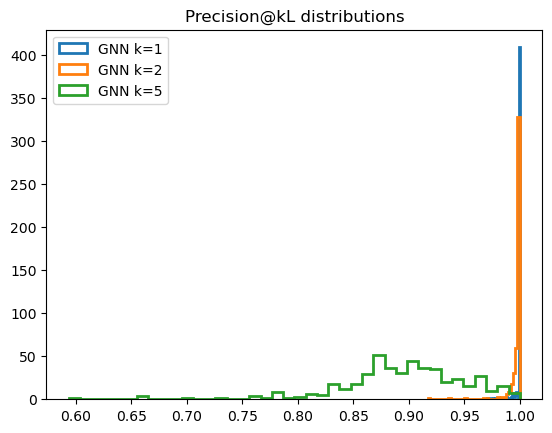

In [ ]:
k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, histtype='step',linewidth=2, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [26]:
k=5
precision= topk_L_precision(model, test_loader, device, ratio=k)[1]
print(precision)
print(max(precision))
print(precision.index(max(precision)))

[0.914545476436615, 0.824999988079071, 0.8660194277763367, 0.9033112525939941, 0.8519336581230164, 0.6977778077125549, 0.7917874455451965, 0.845714271068573, 0.8529412150382996, 0.9514285326004028, 0.9445086717605591, 0.8056795001029968, 0.8481928110122681, 0.9448577761650085, 0.8622222542762756, 0.8472727537155151, 0.5666667222976685, 0.9623188972473145, 0.9305785298347473, 0.934384822845459, 0.9060975909233093, 0.8233502507209778, 0.8826666474342346, 0.8708333969116211, 0.7726315259933472, 0.915433406829834, 0.9320513010025024, 0.7687203884124756, 0.92580646276474, 0.8869564533233643, 0.8571428656578064, 0.9004016518592834, 0.9039577841758728, 0.8566038012504578, 0.7789915800094604, 0.9225225448608398, 0.9164490699768066, 0.8055299520492554, 0.9355931878089905, 0.9191919565200806, 0.8242038488388062, 0.9157894253730774, 0.9152941107749939, 0.8977272510528564, 0.8797385692596436, 0.845714271068573, 0.947706401348114, 0.9458563327789307, 0.9229007959365845, 0.6681817770004272, 0.714163

Data(x=[39, 16], edge_index=[2, 1482], edge_attr=[1482, 1], y=[1482, 1], edge_mask=[1482], pair_mask=[1482], L=39)


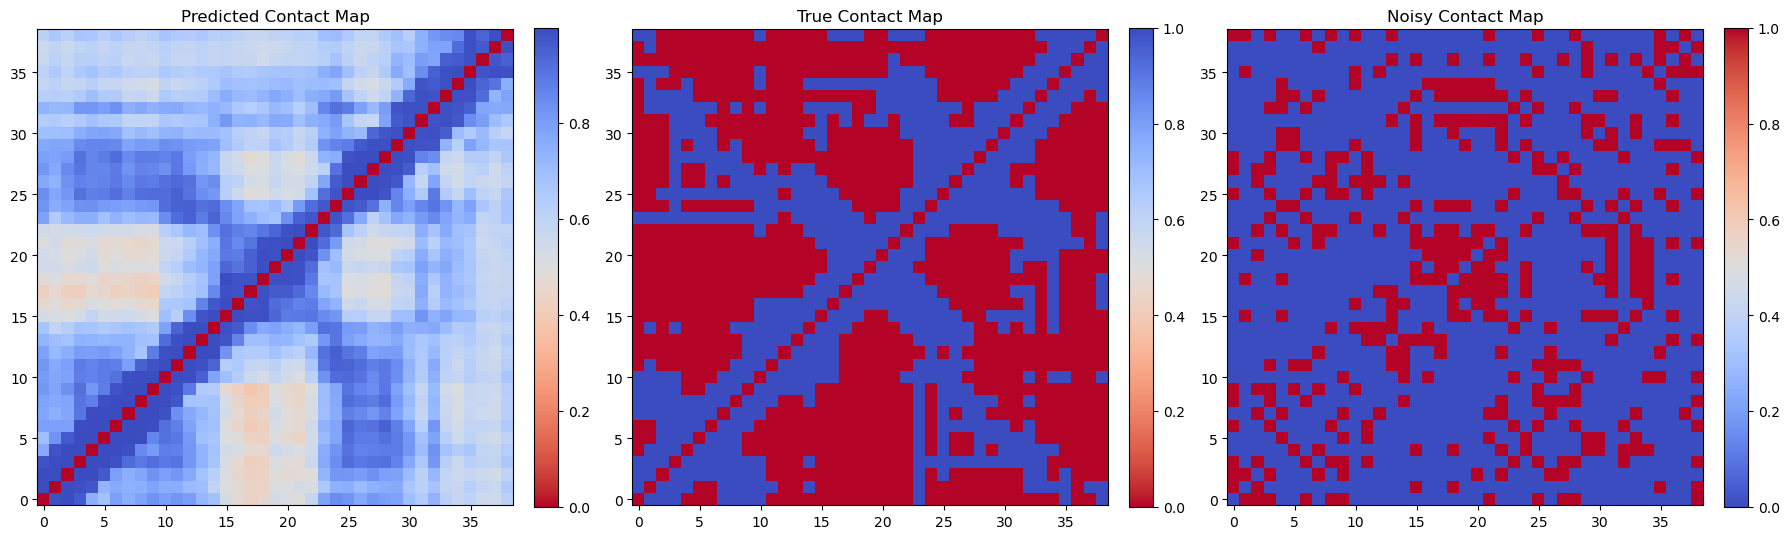

In [30]:
pos=124
#best case

i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)



scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.8
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Now we can test this on real DCA data

In [ ]:
# instead of this we use the test set


# #test on DCA data

# folder_path = folder_DCA

# dca_data = []
# for file in os.listdir(folder_path):
#     if file.endswith(".pkl"):
#         full_path = os.path.join(folder_path, file)
        
#         with open(full_path, "rb") as f:
#             loaded = pickle.load(f)

#         sequence=loaded['sequence']
#         distance_map=loaded['distance_map']
#         contact_map_DCA=loaded['dca']

#         #each DCA score is transformed into a contact map with 5L contacts
#         k = 5*len(sequence)  
#         binary_map = top_k_mask(contact_map_DCA, k)
        
#         data = build_graph_contact(binary_map, distance_map)
        
#         dca_data.append(data)

# test_dca_loader = DataLoader(dca_data, batch_size=1, shuffle=False)

Validation ROC AUC GNN: 0.9089547972249751
Validation ROC AUC DCA: 0.7278826305419349


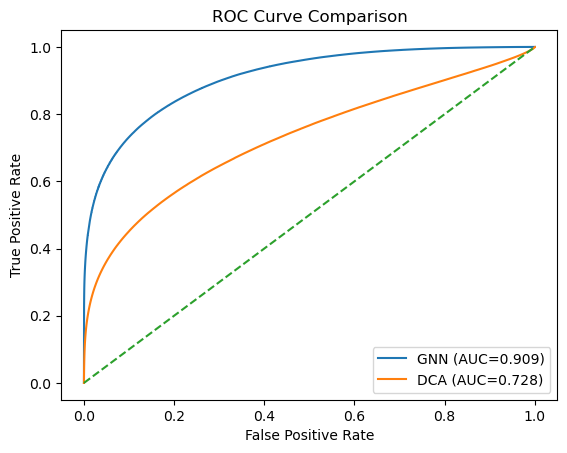

PR AUC GNN: 0.6875484124690107
PR AUC DCA: 0.40158430373699566


/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


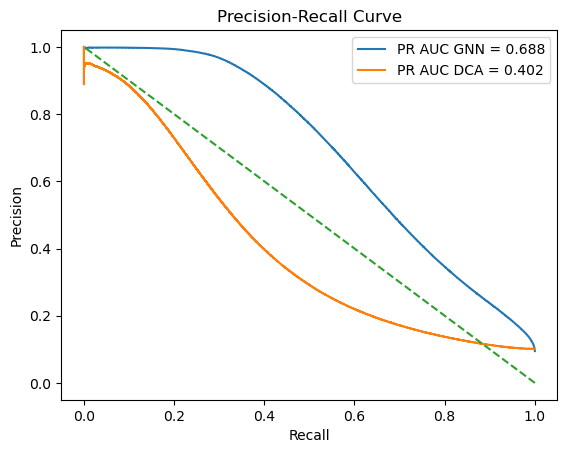

/tmp/ipykernel_3986307/1237197836.py:184: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_3986307/1237197836.py:187: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(


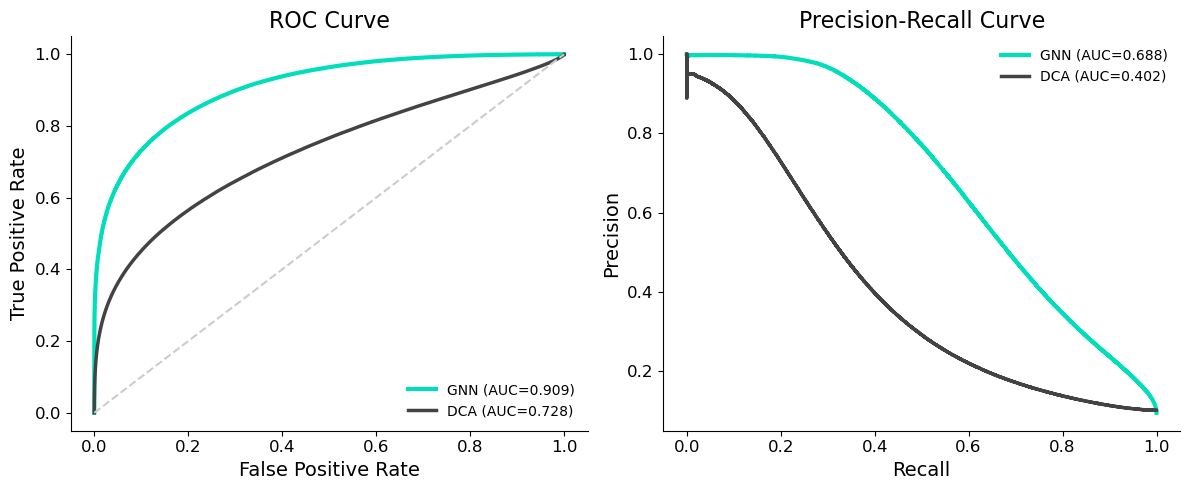

In [21]:
#DCA scores
all_scores = []
all_labels = []

min_sep=minimum_separation

folder_path = folder_DCA
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)

        sequence = loaded['sequence']
        distance_map = loaded['distance_map']
        contact_map_DCA = loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        
        L = len(sequence)
        i, j = np.indices((L, L))

        mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
        # Flatten
        scores = contact_map_DCA[mask].flatten()
        labels = true_contact_map[mask].flatten()

        all_scores.append(scores)
        all_labels.append(labels)

all_scores = np.concatenate(all_scores)
all_labels = np.concatenate(all_labels)


#Model scores
model.eval()

all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)

    with torch.no_grad():
        pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)


print("Validation ROC AUC GNN:", roc_auc)


fpr_dca, tpr_dca, _ = roc_curve(all_labels, all_scores)
roc_auc_dca = auc(fpr_dca, tpr_dca)


print("Validation ROC AUC DCA:", roc_auc_dca)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")
plt.plot(fpr_dca, tpr_dca, label=f"DCA (AUC={roc_auc_dca:.3f})")


plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)



precision_dca, recall_dca, _ = precision_recall_curve(all_labels, all_scores)
pr_auc_dca = auc(recall_dca, precision_dca)


print("PR AUC DCA:", pr_auc_dca)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot(recall_dca, precision_dca, label=f"PR AUC DCA = {pr_auc_dca:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()





mint = "#00DEBA"
darkgray = "#434343"
light2 = "#CCCCCC"
coral = "#FF7F50"

# ------------------
# Figure
# ------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(
    fpr, tpr,
    color=mint,
    lw=3,
    label=f"GNN (AUC={roc_auc:.3f})"
)

axes[0].plot(
    fpr_dca, tpr_dca,
    color=darkgray,
    lw=2.5,
    label=f"DCA (AUC={roc_auc_dca:.3f})"
)

axes[0].plot(
    [0, 1], [0, 1],
    "--",
    color=light2
)

axes[0].set_xlabel("False Positive Rate", fontsize=14)
axes[0].set_ylabel("True Positive Rate", fontsize=14)
axes[0].set_title("ROC Curve", fontsize=16)
axes[0].legend(frameon=False)

# Precision-Recall
axes[1].plot(
    recall, precision,
    color=mint,
    lw=3,
    label=f"GNN (AUC={pr_auc:.3f})"
)

axes[1].plot(
    recall_dca, precision_dca,
    color=darkgray,
    lw=2.5,
    label=f"DCA (AUC={pr_auc_dca:.3f})"
)

axes[1].set_xlabel("Recall", fontsize=14)
axes[1].set_ylabel("Precision", fontsize=14)
axes[1].set_title("Precision-Recall Curve", fontsize=16)

axes[1].legend(frameon=False)

# Clean publication-style axes
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=12)

plt.tight_layout()


plt.savefig(
    "/home/fabio/Internship/Images/ROC_PR_GNN_contacts_contacts_true.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()

In [38]:
#precision for the GNN and DCA

#GNN precision
k=2

prec=[]

for batch in test_loader:
    batch = batch.to(device)

    #accuracy for a single batch
    with torch.no_grad():
        pred_logits = model(batch)
        scores = torch.sigmoid(pred_logits.squeeze(-1))
    

    mask = batch.edge_mask & batch.pair_mask
    scores = scores[mask]
    true_contacts = batch.y.squeeze(-1)[mask]

    L = batch.L
    topk = int(k * L)

    topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

    topk_true = true_contacts[topk_idx]

    num_correct = topk_true.sum()
    precision = (num_correct / len(topk_true)).item()
    prec.append(precision)
print(np.mean(prec))


#DCA precision
prec_dca=[]
min_sep = minimum_separation
folder_path=folder_DCA
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)

        sequence = loaded['sequence']
        distance_map = loaded['distance_map']
        contact_map_DCA = loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        
        L = len(sequence)
        i, j = np.indices((L, L))

        mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
        # Flatten and go to torch
        scores = torch.tensor(contact_map_DCA[mask].flatten(), dtype=torch.float)
        labels = torch.tensor(true_contact_map[mask].flatten(), dtype=torch.float)

        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

        topk_true = labels[topk_idx]

        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec_dca.append(precision)
print(np.mean(prec_dca))



0.9919072730472674
0.7527846958796082


In [39]:
#for the GNN it's possible to obtain the same with the function topk_L_precision
k=2

print("Top-k*L precision GNN:", topk_L_precision(model, test_loader, device, ratio=k)[0])


Top-k*L precision GNN: 0.9919072730472674


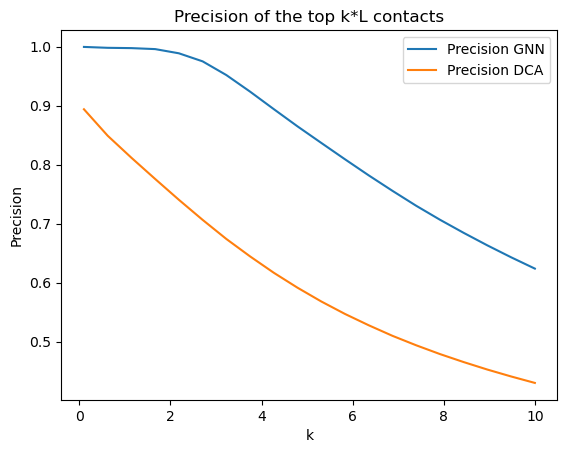

In [40]:
#precision in function of the number of contact to predict
total_k=np.linspace(0.1,10,20)
p_GNN=[]
p_DCA=[]
for k in total_k:

    #GNN    
    prec=[]

    for batch in test_loader:
        batch = batch.to(device)

        #accuracy for a single batch
        with torch.no_grad():
            pred_logits = model(batch)
            scores = torch.sigmoid(pred_logits.squeeze(-1))
        

        mask = batch.edge_mask & batch.pair_mask
        scores = scores[mask]
        true_contacts = batch.y.squeeze(-1)[mask]

        L = batch.L
        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

        topk_true = true_contacts[topk_idx]

        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec.append(precision)
    
    p_GNN.append(np.mean(prec))

    #DCA

    prec_dca=[]


    min_sep=minimum_separation

    folder_path=folder_DCA
    for file in os.listdir(folder_path):
        if file.endswith(".pkl"):
            with open(os.path.join(folder_path, file), "rb") as f:
                loaded = pickle.load(f)

            sequence = loaded['sequence']
            distance_map = loaded['distance_map']
            contact_map_DCA = loaded['dca']

            true_contact_map = contact_from_distance(distance_map, threshold=8.0)
            
            L = len(sequence)
            i, j = np.indices((L, L))

            mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
            # Flatten and go to torch
            scores = torch.tensor(contact_map_DCA[mask].flatten(), dtype=torch.float)
            labels = torch.tensor(true_contact_map[mask].flatten(), dtype=torch.float)

            topk = int(k * L)

            topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

            topk_true = labels[topk_idx]

            num_correct = topk_true.sum()
            precision = (num_correct / len(topk_true)).item()
            prec_dca.append(precision)

    p_DCA.append(np.mean(prec_dca))
    

plt.figure()

plt.plot(total_k, p_GNN, label=f"Precision GNN")
plt.plot(total_k, p_DCA, label=f"Precision DCA")


plt.xlabel("k")
plt.ylabel("Precision")
plt.title("Precision of the top k*L contacts")
plt.legend()

plt.show()

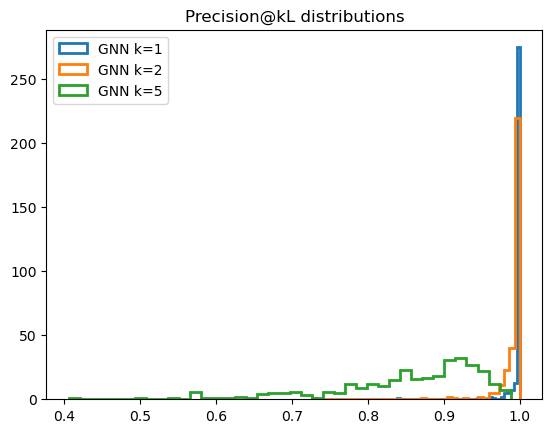

In [41]:
k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, histtype='step',linewidth=2, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [42]:
k=1
precision= topk_L_precision(model, test_loader, device, ratio=k)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))
print(max(precision))
print(precision.index(max(precision)))

[0.9818181395530701, 0.9855769872665405, 1.0, 1.0, 1.0, 1.0, 0.9975845217704773, 1.0, 1.0, 1.0, 1.0, 0.9837728142738342, 0.9999999403953552, 1.0, 1.0, 0.9999999403953552, 1.0, 1.0, 0.9999999403953552, 1.0, 0.9999999403953552, 1.0, 1.0, 1.0, 0.9842105507850647, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999403953552, 0.9973615407943726, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9892857074737549, 0.9999999403953552, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9855769872665405, 1.0, 1.0, 1.0, 0.9960000514984131, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999403953552, 1.0, 0.9881423115730286, 1.0, 0.9999999403953552, 0.9999999403953552, 1.0, 0.9999999403953552, 1.0, 1.0, 1.0, 0.9922480583190918, 1.0, 0.995555579662323, 1.0, 1.0, 1.0, 1.0, 0.98333340883255, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9943342804908752, 0.9999999403953552, 0.9623287320137024, 1.0, 1.0, 1.0, 0.9967426657676697, 1.0, 1.0, 1.0, 1.0, 0.9459459781646729, 0.9999999403953552, 1.0, 0.9811320900

Data(x=[110, 16], edge_index=[2, 11990], edge_attr=[11990, 1], y=[11990, 1], edge_mask=[11990], pair_mask=[11990], L=110)


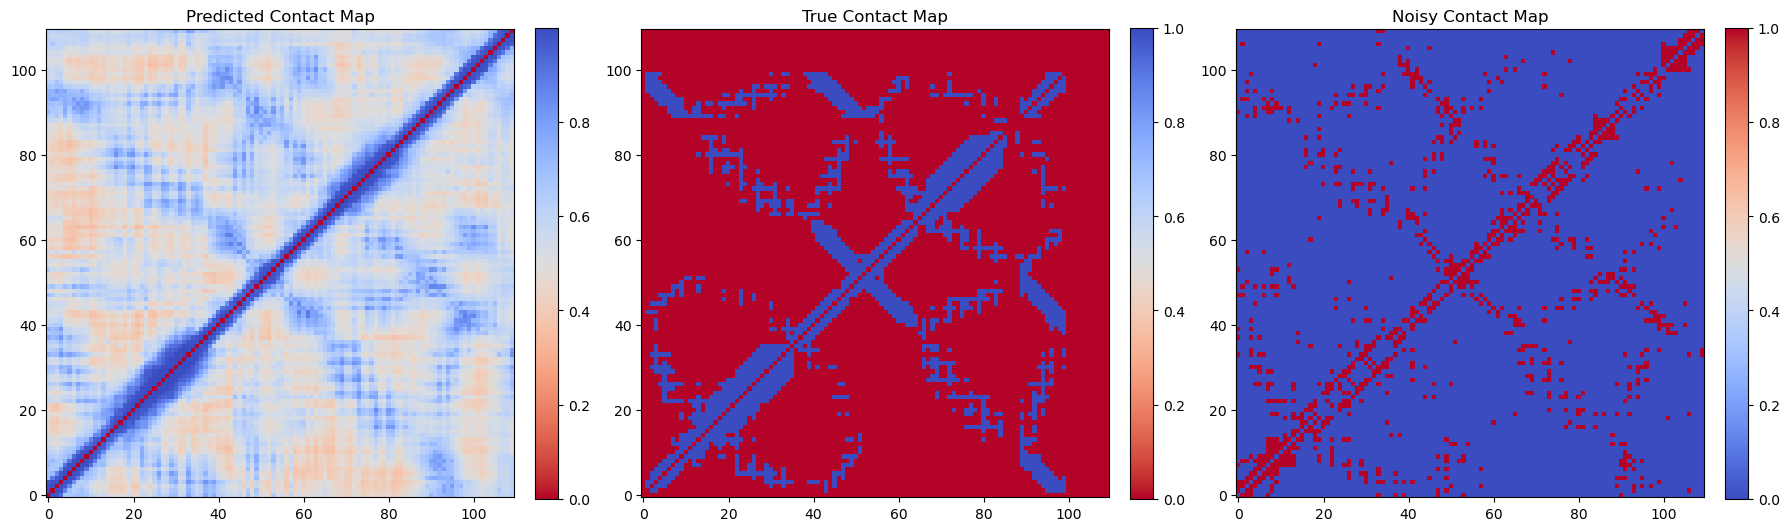

In [45]:
pos=0


i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)

mask = batch.edge_mask #& batch.pair_mask

scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.9
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [19]:
#precision in function of the number of contact to predict
total_k_0=np.linspace(0.5,10,40)
p_GNN_0=[]
p_DCA_0=[]
for k in total_k_0:

    #GNN    
    prec=[]

    for batch in test_loader:
        batch = batch.to(device)

        #accuracy for a single batch
        with torch.no_grad():
            pred_logits = model(batch)
            scores = torch.sigmoid(pred_logits.squeeze(-1))
        

        mask = batch.edge_mask & batch.pair_mask
        scores = scores[mask]
        true_contacts = batch.y.squeeze(-1)[mask]

        L = batch.L
        topk = int(k * L)

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

        topk_true = true_contacts[topk_idx]

        num_correct = topk_true.sum()
        precision = (num_correct / len(topk_true)).item()
        prec.append(precision)
    
    p_GNN_0.append(np.mean(prec))

    #DCA

    prec_dca=[]


    min_sep=minimum_separation

    folder_path=folder_DCA
    for file in os.listdir(folder_path):
        if file.endswith(".pkl"):
            with open(os.path.join(folder_path, file), "rb") as f:
                loaded = pickle.load(f)

            sequence = loaded['sequence']
            distance_map = loaded['distance_map']
            contact_map_DCA = loaded['dca']

            true_contact_map = contact_from_distance(distance_map, threshold=8.0)
            
            L = len(sequence)
            i, j = np.indices((L, L))

            mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
            # Flatten and go to torch
            scores = torch.tensor(contact_map_DCA[mask].flatten(), dtype=torch.float)
            labels = torch.tensor(true_contact_map[mask].flatten(), dtype=torch.float)

            topk = int(k * L)

            topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

            topk_true = labels[topk_idx]

            num_correct = topk_true.sum()
            precision = (num_correct / len(topk_true)).item()
            prec_dca.append(precision)

    p_DCA_0.append(np.mean(prec_dca))

In [20]:
#we want to see if the prediction for not near-diagonal terms have been improved or not
min_sep = 5

total_k_5=np.linspace(0.5,5,40)
p_GNN_5=[]
p_DCA_5=[]

for k in total_k_5:


    prec = []

    for batch in test_loader:
        batch = batch.to(device)

        with torch.no_grad():
            pred_logits = model(batch)
            scores = torch.sigmoid(pred_logits.squeeze(-1))
            
        # keep only valid pairs and exclude diagonal / near-diagonal pairs
        sep_mask = (batch.edge_index[0] - batch.edge_index[1]).abs() >= min_sep
        upper_mask = batch.edge_index[0] < batch.edge_index[1]
        mask = batch.edge_mask & batch.pair_mask & sep_mask & upper_mask

        scores = scores[mask]
        true_contacts = batch.y.squeeze(-1)[mask]

        L = batch.L
        topk = int(k * L)

        if scores.numel() == 0:
            continue

        topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

        topk_true = true_contacts[topk_idx]


        precision = topk_true.float().mean().item() if len(topk_true) > 0 else 0.0


        prec.append(precision)


    p_GNN_5.append(np.mean(prec))


    prec=[]
    folder_path=folder_DCA
    for file in os.listdir(folder_path):
        if file.endswith(".pkl"):
            with open(os.path.join(folder_path, file), "rb") as f:
                loaded = pickle.load(f)

            sequence = loaded['sequence']
            distance_map = loaded['distance_map']
            contact_map_DCA = loaded['dca']

            true_contact_map = contact_from_distance(distance_map, threshold=8.0)
            
            L = len(sequence)
            i, j = np.indices((L, L))

            mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
            # Flatten
            scores = torch.tensor(contact_map_DCA[mask].flatten())
            labels = torch.tensor(true_contact_map[mask].flatten())

            topk = int(k * L)

            topk_idx = torch.topk(scores, k=min(topk, scores.numel())).indices

            topk_true = labels[topk_idx]

            precision = topk_true.float().mean().item() if len(topk_true) > 0 else 0.0

            prec.append(precision)


    p_DCA_5.append(np.mean(prec))


GNN precision: [np.float64(0.804547475502133)]
DCA precision: [np.float64(0.7265766032474458)]
GNN precision: [np.float64(0.804547475502133), np.float64(0.7848402897294718)]
DCA precision: [np.float64(0.7265766032474458), np.float64(0.703745292732343)]
GNN precision: [np.float64(0.804547475502133), np.float64(0.7848402897294718), np.float64(0.7746616709775056)]
DCA precision: [np.float64(0.7265766032474458), np.float64(0.703745292732343), np.float64(0.6818367303787592)]
GNN precision: [np.float64(0.804547475502133), np.float64(0.7848402897294718), np.float64(0.7746616709775056), np.float64(0.766413435720788)]
DCA precision: [np.float64(0.7265766032474458), np.float64(0.703745292732343), np.float64(0.6818367303787592), np.float64(0.6611283749788236)]
GNN precision: [np.float64(0.804547475502133), np.float64(0.7848402897294718), np.float64(0.7746616709775056), np.float64(0.766413435720788), np.float64(0.7533775898642814)]
DCA precision: [np.float64(0.7265766032474458), np.float64(0.70374

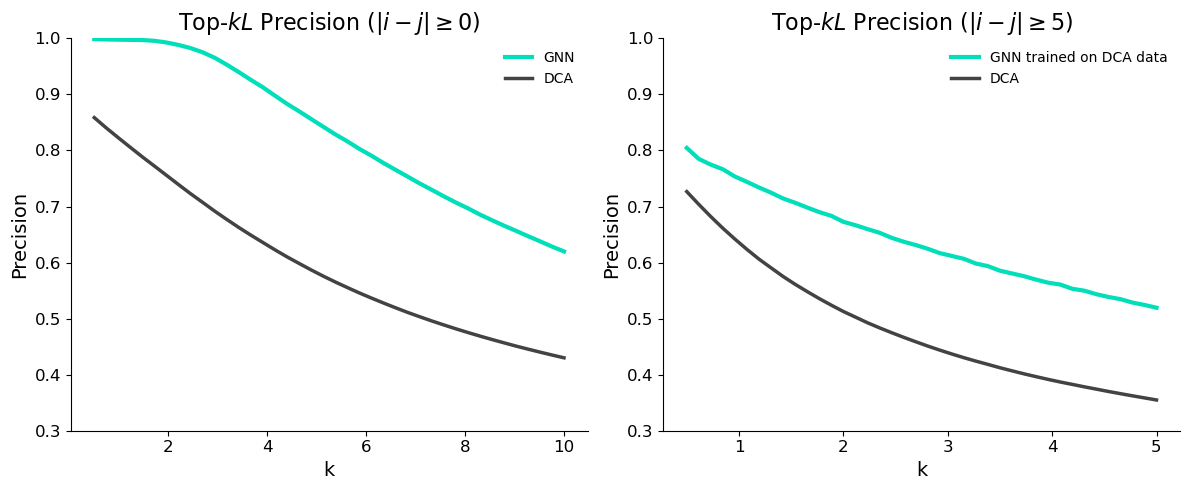

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mint = "#00DEBA"
darkgray = "#434343"
light2 = "#CCCCCC"
coral = "#FF7F50"
# ------------------
# Sequence separation >= 0
# ------------------
axes[0].plot(
    total_k_0,
    p_GNN_0,
    color=mint,
    lw=3,
    label="GNN"
)

axes[0].plot(
    total_k_0,
    p_DCA_0,
    color=darkgray,
    lw=2.5,
    label="DCA"
)

axes[0].set_xlabel("k", fontsize=14)
axes[0].set_ylabel("Precision", fontsize=14)
axes[0].set_title(r"Top-$kL$ Precision ($|i-j| \geq 0$)", fontsize=16)
axes[0].legend(frameon=False)

# ------------------
# Sequence separation >= 5
# ------------------
axes[1].plot(
    total_k_5,
    p_GNN_5,
    color=mint,
    lw=3,
    label="GNN trained on DCA data"
)


axes[1].plot(
    total_k_5,
    p_DCA_5,
    color=darkgray,
    lw=2.5,
    label="DCA"
)

axes[1].set_xlabel("k", fontsize=14)
axes[1].set_ylabel("Precision", fontsize=14)
axes[1].set_title(r"Top-$kL$ Precision ($|i-j| \geq 5$)", fontsize=16)
axes[1].legend(frameon=False)

# Publication-style axes
for ax in axes:
    ax.set_ylim(0.3, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=12)

plt.tight_layout()

plt.savefig(
    "/home/fabio/Internship/Images/Topk_precision_contacts_contacts.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()

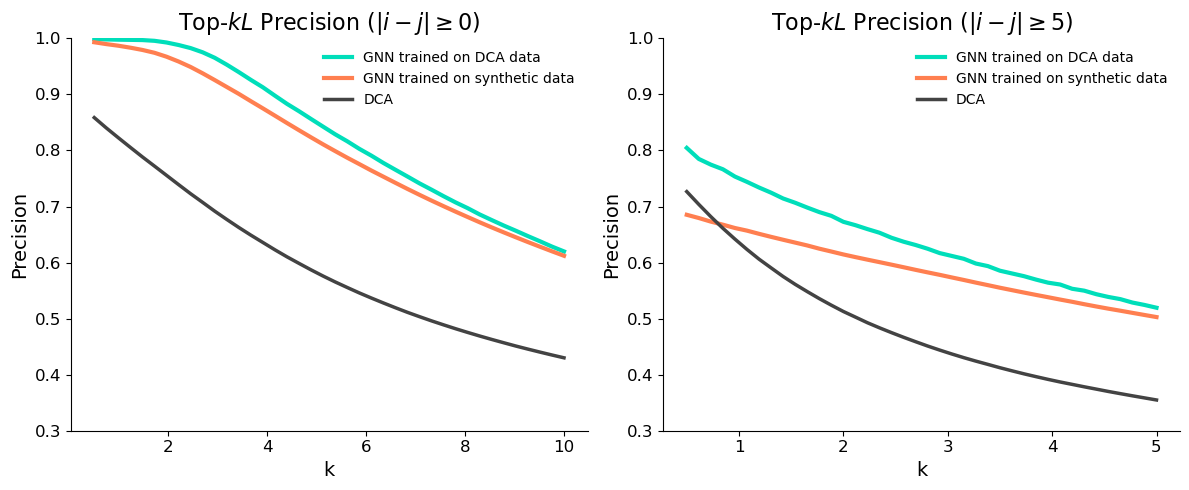

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ------------------
# Sequence separation >= 0
# ------------------
axes[0].plot(
    total_k_0,
    p_GNN_0,
    color=mint,
    lw=3,
    label="GNN trained on DCA data"
)


import pickle

with open("p_GNN_0_fake.pkl", "rb") as f:
    p_GNN_0_fake = pickle.load(f)

axes[0].plot(
    total_k_0,
    p_GNN_0_fake,
    color=coral,
    lw=3,
    label="GNN trained on synthetic data"
)

axes[0].plot(
    total_k_0,
    p_DCA_0,
    color=darkgray,
    lw=2.5,
    label="DCA"
)


axes[0].set_xlabel("k", fontsize=14)
axes[0].set_ylabel("Precision", fontsize=14)
axes[0].set_title(r"Top-$kL$ Precision ($|i-j| \geq 0$)", fontsize=16)
axes[0].legend(frameon=False)

# ------------------
# Sequence separation >= 5
# ------------------
axes[1].plot(
    total_k_5,
    p_GNN_5,
    color=mint,
    lw=3,
    label="GNN trained on DCA data"
)


import pickle

with open("p_GNN_5_fake.pkl", "rb") as f:
    p_GNN_5_fake = pickle.load(f)
    
axes[1].plot(
    total_k_5,
    p_GNN_5_fake,
    color=coral,
    lw=3,
    label="GNN trained on synthetic data"
)

axes[1].plot(
    total_k_5,
    p_DCA_5,
    color=darkgray,
    lw=2.5,
    label="DCA"
)

axes[1].set_xlabel("k", fontsize=14)
axes[1].set_ylabel("Precision", fontsize=14)
axes[1].set_title(r"Top-$kL$ Precision ($|i-j| \geq 5$)", fontsize=16)
axes[1].legend(frameon=False)

# Publication-style axes
for ax in axes:
    ax.set_ylim(0.3, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=12)

plt.tight_layout()

plt.savefig(
    "/home/fabio/Internship/Images/Topk_precision_comparison.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()